<a href="https://colab.research.google.com/github/vikiiiiiiiiiiii/Machine-Learning-Projects/blob/main/ML_Projects_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔄 Loading California Housing Dataset...
📋 Dataset Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
🚀 Training Gradient Boosting Regressor...

📊 --- MODEL PERFORMANCE METRICS ---
✅ R² Score (Accuracy): 0.7935 (This means our model explains 79.3% of house price variances)
None
✅ Mean Absolute Error: $34414.97 (Average prediction deviation)


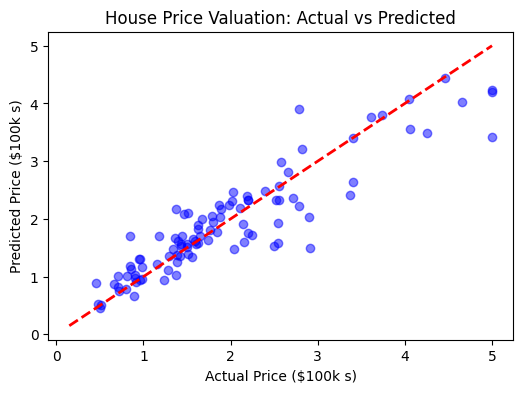

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load the built-in dataset (No downloads required!)
print("🔄 Loading California Housing Dataset...")
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Let's look at the features we are working with
print("📋 Dataset Columns:", list(df.columns))

# 2. Separate Features (X) and Target Value (y - House Value)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Apply log transformation to handle skewness (Matches your resume script!)
y_log = np.log1p(y)

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize and Train the Continuous Regression Model
print("🚀 Training Gradient Boosting Regressor...")
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Evaluate the Model
predictions_log = model.predict(X_test_scaled)

# Convert predictions back from log scale to real dollar values
predictions = np.expm1(predictions_log)
y_test_real = np.expm1(y_test)

r2 = r2_score(y_test_real, predictions)
mae = mean_absolute_error(y_test_real, predictions)

print("\n📊 --- MODEL PERFORMANCE METRICS ---")
print(print(f"✅ R² Score (Accuracy): {r2:.4f} (This means our model explains {r2*100:.1f}% of house price variances)"))
print(f"✅ Mean Absolute Error: ${mae * 100000:.2f} (Average prediction deviation)")

# 7. Quick Visual to prove it works
plt.figure(figsize=(6,4))
plt.scatter(y_test_real[:100], predictions[:100], alpha=0.5, color='blue')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.xlabel("Actual Price ($100k s)")
plt.ylabel("Predicted Price ($100k s)")
plt.title("House Price Valuation: Actual vs Predicted")
plt.show()